In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_books = pd.read_csv('Data/Cleaned_Books_Data.csv')

In [3]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_books['content_soup'])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [4]:
print("Số dòng của Dataframe:", df_books.shape[0])
print("Kích thước ma trận TF-IDF:", tfidf_matrix.shape)
print("Kích thước ma trận Cosine:", cosine_sim.shape)

Số dòng của Dataframe: 889
Kích thước ma trận TF-IDF: (889, 16255)
Kích thước ma trận Cosine: (889, 889)


In [5]:
indices = pd.Series(df_books.index, index=df_books['title']).drop_duplicates()
def get_recommendation(user_input, cosine_sim=cosine_sim, df=df_books):
    search_term = str(user_input).lower().strip()
    matched_books = df[df['title'].str.lower().str.contains(search_term, na=False)]

    if matched_books.empty:
        print(f"Không tìm thấy sách nào chứa từ khóa: '{user_input}'")
        return None, None

    target_book = matched_books.iloc[0]
    target_title = target_book['title']

    idx = indices[target_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]

    book_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    result_df = df.iloc[book_indices].copy()
    result_df['similarity_score'] = scores

    return target_title, result_df

In [6]:
def plot_recommendations(target_title, result_df):
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x='similarity_score',
        y='title',
        data=result_df,
        hue='title',
        palette="viridis",
        legend=False
    )

    plt.title(f'Top 5 Sách Gợi Ý Cho: "{target_title}"', fontsize=14, fontweight='bold')
    plt.xlabel('Độ Tương Đồng (Cosine Score)', fontsize=12)
    plt.ylabel('Tên Sách', fontsize=12)
    plt.xlim(0, 1)

    # Gắn số liệu
    for i, v in enumerate(result_df['similarity_score']):
        ax.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

Hệ thống xác nhận tìm sách: The Eye of the World


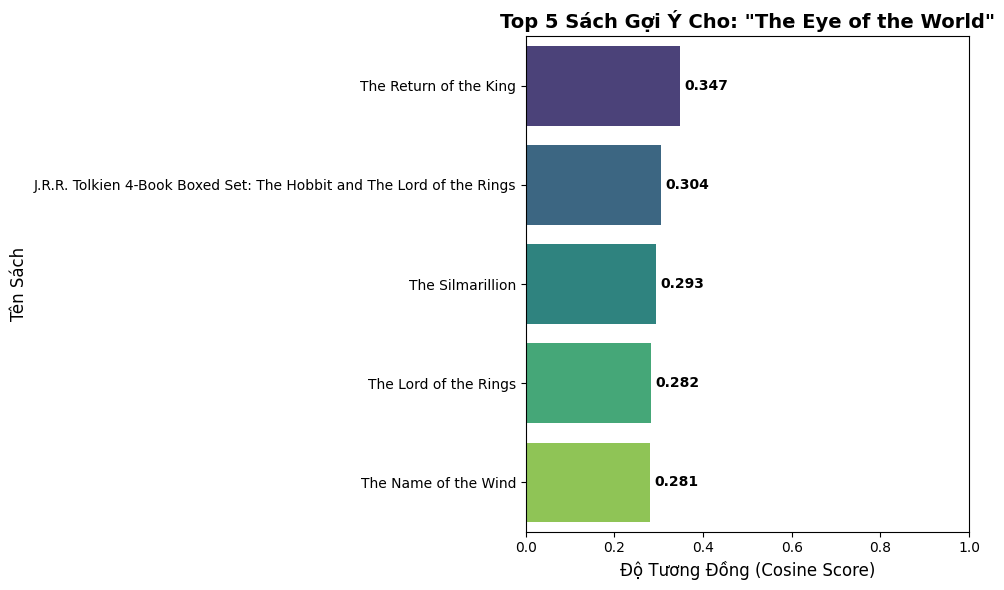

In [7]:
ten_sach_goc, du_lieu_goi_y = get_recommendation(' eye of the world ')

if du_lieu_goi_y is not None:
    print(f"Hệ thống xác nhận tìm sách: {ten_sach_goc}")
    plot_recommendations(ten_sach_goc, du_lieu_goi_y)

In [8]:
def test_model_accuracy(title, cosine_sim=cosine_sim, df=df_books):
    if title not in indices:
        return "Sách không tồn tại trong dữ liệu!"

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]

    print(f"=== TOP 5 GỢI Ý CHO SÁCH: '{title}' ===")
    print(f"Tác giả gốc: {df['author'].iloc[idx]} | Thể loại gốc: {df['genres'].iloc[idx]}\n")

    for i, (book_idx, score) in enumerate(sim_scores):
        rec_title = df['title'].iloc[book_idx]
        rec_author = df['author'].iloc[book_idx]
        rec_genres = df['genres'].iloc[book_idx]

        print(f"Hạng {i+1}: {rec_title}")
        print(f"  - Tác giả: {rec_author}")
        print(f"  - Thể loại: {rec_genres}")
        print(f"  - Điểm Cosine: {score:.3f}\n")

test_model_accuracy('The Eye of the World')

=== TOP 5 GỢI Ý CHO SÁCH: 'The Eye of the World' ===
Tác giả gốc: Robert Jordan | Thể loại gốc: Fantasy,Fiction,Epic Fantasy,Audiobook,High Fantasy,Science Fiction Fantasy,Adventure

Hạng 1: The Return of the King
  - Tác giả: J.R.R. Tolkien
  - Thể loại: Fantasy,Fiction,Classics,Adventure,High Fantasy,Audiobook,Epic Fantasy
  - Điểm Cosine: 0.347

Hạng 2: J.R.R. Tolkien 4-Book Boxed Set: The Hobbit and The Lord of the Rings
  - Tác giả: J.R.R. Tolkien
  - Thể loại: Fantasy,Fiction,Classics,Adventure,Science Fiction Fantasy,Epic Fantasy,High Fantasy
  - Điểm Cosine: 0.304

Hạng 3: The Silmarillion
  - Tác giả: J.R.R. Tolkien
  - Thể loại: Fantasy,Fiction,Classics,High Fantasy,Epic Fantasy,Science Fiction Fantasy,Mythology
  - Điểm Cosine: 0.293

Hạng 4: The Lord of the Rings
  - Tác giả: J.R.R. Tolkien
  - Thể loại: Fantasy,Classics,Fiction,Adventure,Science Fiction Fantasy,High Fantasy,Epic Fantasy
  - Điểm Cosine: 0.282

Hạng 5: The Name of the Wind
  - Tác giả: Patrick Rothfuss
  - 

D:\ANACONDA\envs\my-env\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Hoàn tất! Đang vẽ biểu đồ Khuỷu tay...


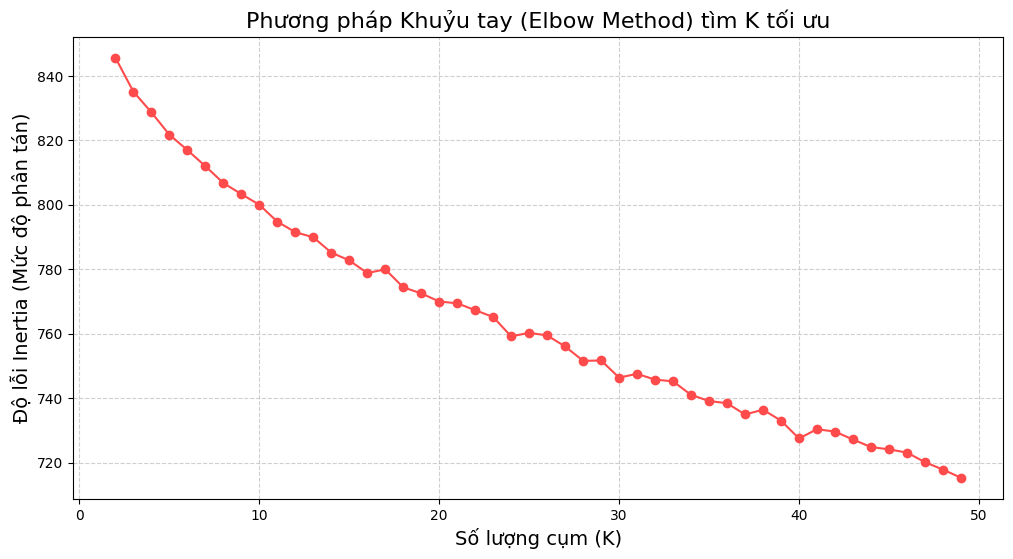

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
inertia_values = []
K_range = range(2, 50)

for k in K_range:
    kmeans = KMeans(n_clusters=k,init='k-means++', random_state=42)
    kmeans.fit(tfidf_matrix)
    inertia_values.append(kmeans.inertia_)

print("Hoàn tất! Đang vẽ biểu đồ Khuỷu tay...")

# Vẽ biểu đồ Phương pháp Khuỷu tay
plt.figure(figsize=(12, 6))
plt.plot(K_range, inertia_values, marker='o', linestyle='-', color='#FF4B4B')
plt.title('Phương pháp Khuỷu tay (Elbow Method) tìm K tối ưu', fontsize=16)
plt.xlabel('Số lượng cụm (K)', fontsize=14)
plt.ylabel('Độ lỗi Inertia (Mức độ phân tán)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
print("K-Means Clustering...")
kmeans = KMeans(n_clusters=10, random_state=42)
df_books['Cluster'] = kmeans.fit_predict(tfidf_matrix)

print("PCA giảm chiều dữ liệu...")
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())
df_books['PCA_X'] = pca_result[:, 0]
df_books['PCA_Y'] = pca_result[:, 1]
print("Hoàn thành")

K-Means Clustering...
PCA giảm chiều dữ liệu...
Hoàn thành


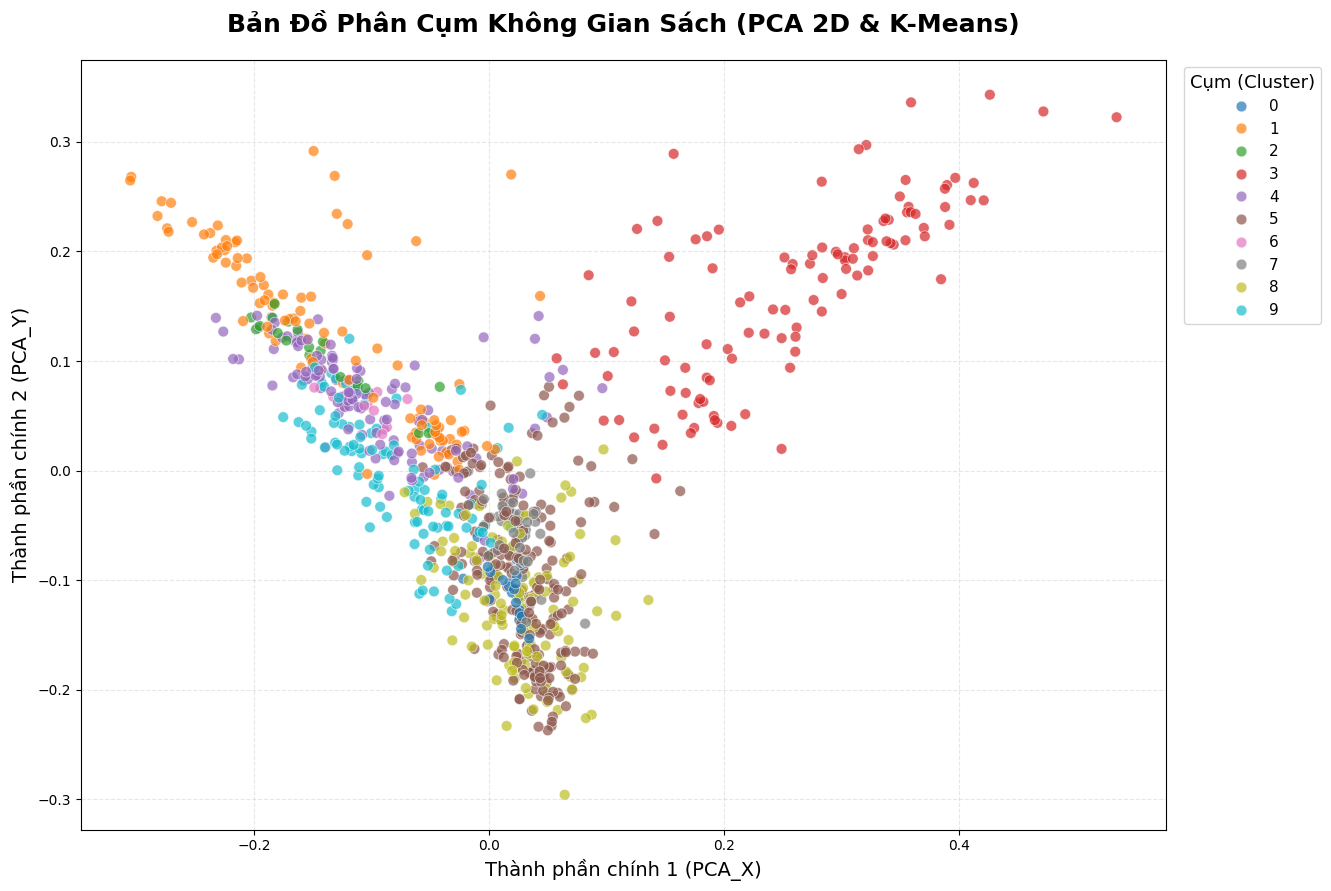

In [11]:
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=df_books,
    x='PCA_X',
    y='PCA_Y',
    hue='Cluster',
    palette='tab10',
    s=60,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Bản Đồ Phân Cụm Không Gian Sách (PCA 2D & K-Means)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Thành phần chính 1 (PCA_X)', fontsize=14)
plt.ylabel('Thành phần chính 2 (PCA_Y)', fontsize=14)

plt.legend(title='Cụm (Cluster)', title_fontsize='13', fontsize='11', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

In [12]:
# Số lượng sách được phân bổ trong mỗi cụm
print(df_books['Cluster'].value_counts())

cluster_id = 1
books_in_cluster = df_books[df_books['Cluster'] == cluster_id][['title', 'author', 'genres']]
print(f"\nCác sách thuộc Cụm {cluster_id}:")
display(books_in_cluster.head(10))

5    221
4    125
8    120
3    109
9    106
1    104
7     51
0     22
2     20
6     11
Name: Cluster, dtype: int64

Các sách thuộc Cụm 1:


,title,author,genres
5,Twilight,Stephenie Meyer,"Fantasy,Young Adult,Romance,Fiction,Vampires,P..."
31,City of Bones,Cassandra Clare,"Fantasy,Young Adult,Romance,Paranormal,Urban F..."
93,Vampire Academy,Richelle Mead,"Fantasy,Young Adult,Vampires,Paranormal,Romanc..."
100,Message in a Bottle,Nicholas Sparks,"Romance,Fiction,Chick Lit,Contemporary,Adult,C..."
103,Club Dead,Charlaine Harris,"Fantasy,Vampires,Paranormal,Urban Fantasy,Roma..."
106,Living Dead in Dallas,Charlaine Harris,"Fantasy,Vampires,Paranormal,Urban Fantasy,Roma..."
111,Souls Unfractured,Tillie Cole,"Dark,Romance,Dark Romance,Contemporary,Abuse,C..."
113,Glass Houses,Rachel Caine,"Vampires,Young Adult,Fantasy,Paranormal,Urban ..."
125,"It Ain't Me, Babe",Tillie Cole,"Romance,Dark Romance,Dark,Contemporary,Abuse,C..."
130,Tears of Tess,Pepper Winters,"Dark,Dark Romance,Romance,BDSM,Erotica,Contemp..."


In [13]:
with open('df_books.pkl', 'wb') as f:
    pickle.dump(df_books, f)
with open('cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)